In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
%matplotlib inline


In [15]:
probes = np.load("segment-field-aberrations.pkl",allow_pickle=True)
probes.keys(),probes["fields"][0].keys(),probes["projections"][0].keys()

(dict_keys(['fields', 'projections']),
 dict_keys(['zenith', 'azimuth', 'n_radial_order', 'pupil_mode', 'coefs_format']),
 dict_keys(['basis', 'coefficients', 'opd', 'coefs_format']))

In [16]:
z = np.asarray([x['zenith']['Arcminute'] for x in probes["fields"]])
a = np.asarray([x['azimuth']['Radian'] for x in probes["fields"]])
x = z*np.cos(a)
y = z*np.sin(a)
triang = tri.Triangulation(x,y)

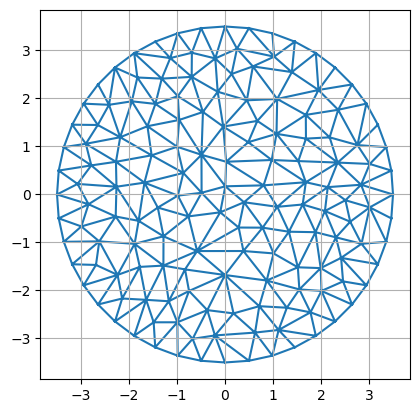

In [17]:
fig,ax = plt.subplots()
ax.triplot(triang)
ax.set_aspect('equal')
ax.grid()

In [18]:
z5 = np.asarray([x['coefficients'][4] for x in probes["projections"]])
z6 = np.asarray([x['coefficients'][5] for x in probes["projections"]])
z7 = np.asarray([x['coefficients'][6] for x in probes["projections"]])
z8 = np.asarray([x['coefficients'][7] for x in probes["projections"]])

{'Segment': {'sid': 1,
  'mirror': {'M2': {'t_xyz': ({'Nm': 0.0}, {'Nm': 20000.0}, {'Nm': 0.0}),
    'r_xyz': ({'MilliArcsec': 1000.0},
     {'MilliArcsec': 0.0},
     {'MilliArcsec': 0.0})}},
  'zeroed': True}}

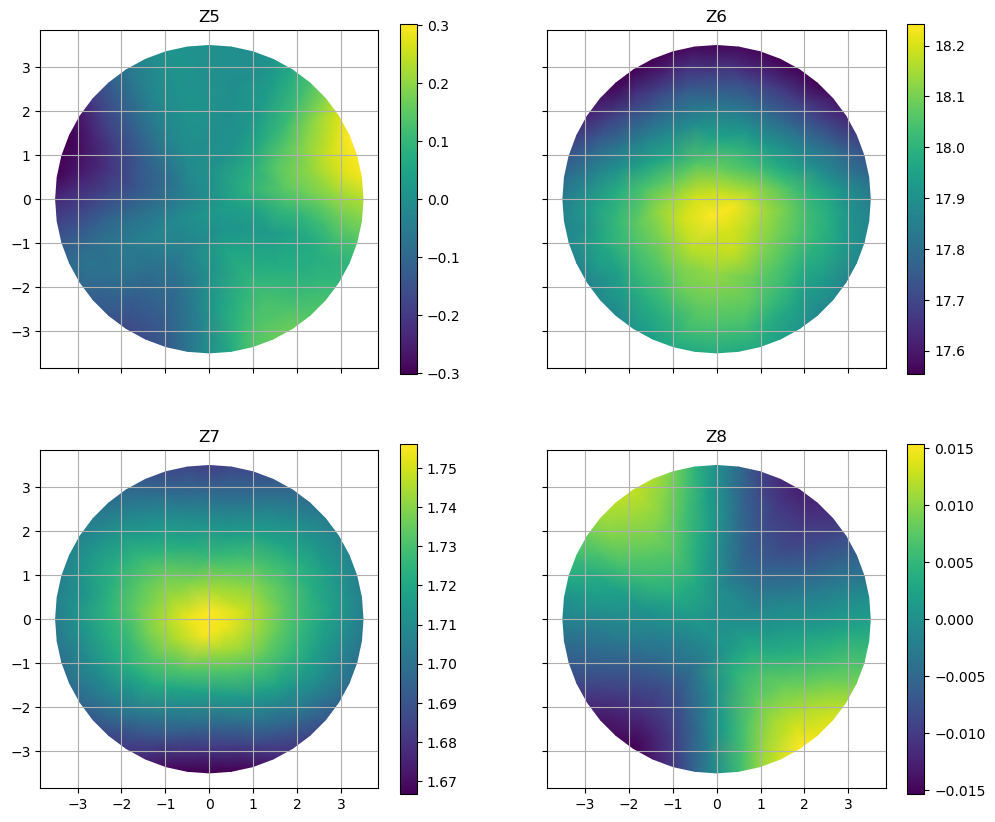

In [19]:
fig,axs = plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(12,10))
ax = axs[0,0]
h = ax.tripcolor(triang,z5,shading="gouraud")
ax.set_aspect('equal')
ax.grid()
fig.colorbar(h,ax=ax)
ax.set_title("Z5")
ax = axs[0,1]
h = ax.tripcolor(triang,z6,shading="gouraud")
ax.set_aspect('equal')
ax.grid()
fig.colorbar(h,ax=ax)
ax.set_title("Z6")
ax = axs[1,0]
h = ax.tripcolor(triang,z7,shading="gouraud")
ax.set_aspect('equal')
ax.grid()
fig.colorbar(h,ax=ax)
ax.set_title("Z7")
ax = axs[1,1]
h=ax.tripcolor(triang,z8,shading="gouraud")
ax.set_aspect('equal')
ax.grid()
fig.colorbar(h,ax=ax)
ax.set_title("Z8")

probes["fields"][0]['pupil_mode']